{'start': [   timestamp  cpu_usage_percent  mem_usage_percent  disk_usage_percent  \
0         0s               15.2               17.2            46.50000   
1         5s               15.5               17.2            33.50000   
2        10s               38.2               17.4            11.53756   
3        15s               31.7               18.4            95.20000   
4        20s               11.9               17.8             3.70000   
5        25s               24.0               18.1            25.60000   
6        30s               66.3               19.2             3.60000   
7        35s               16.1               19.0            17.60000   
8        40s                8.9               18.9             0.40000   
9        45s               35.2               19.0             1.00000   
10       50s               12.6               18.9             4.30000   
11       55s               16.3               18.8            20.20000   
12       60s               

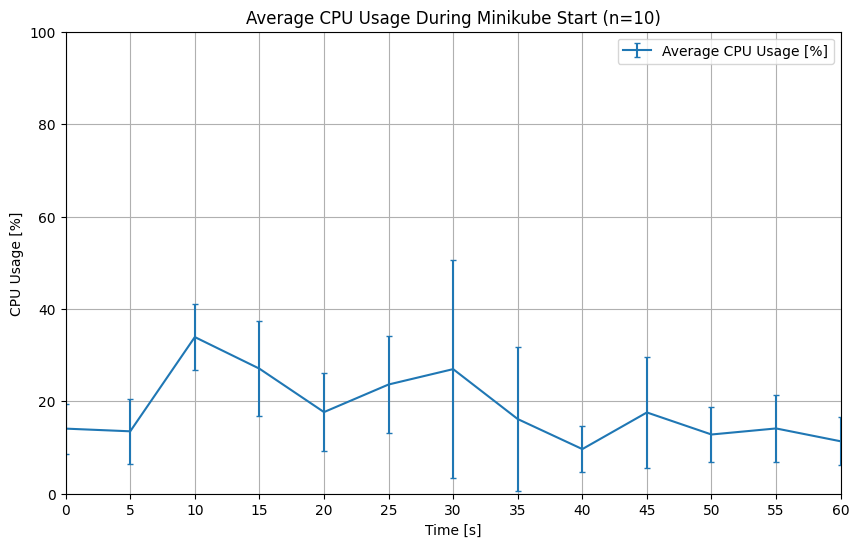

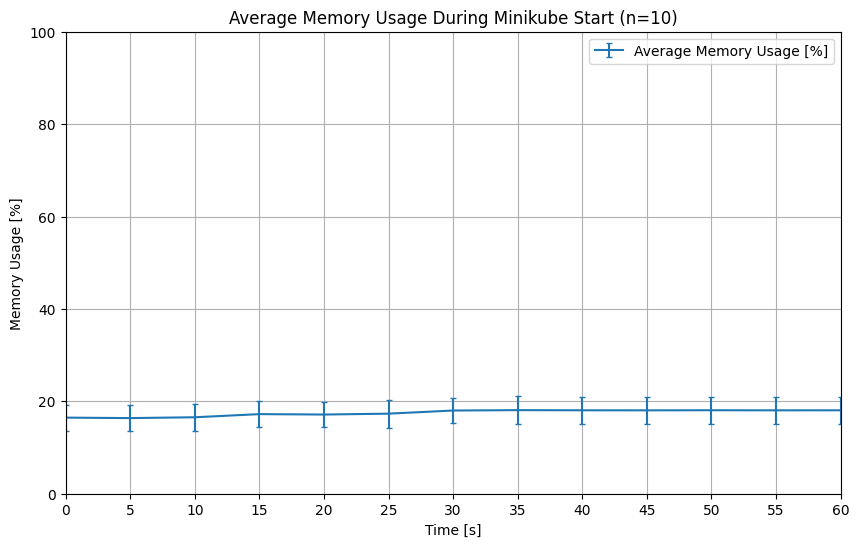

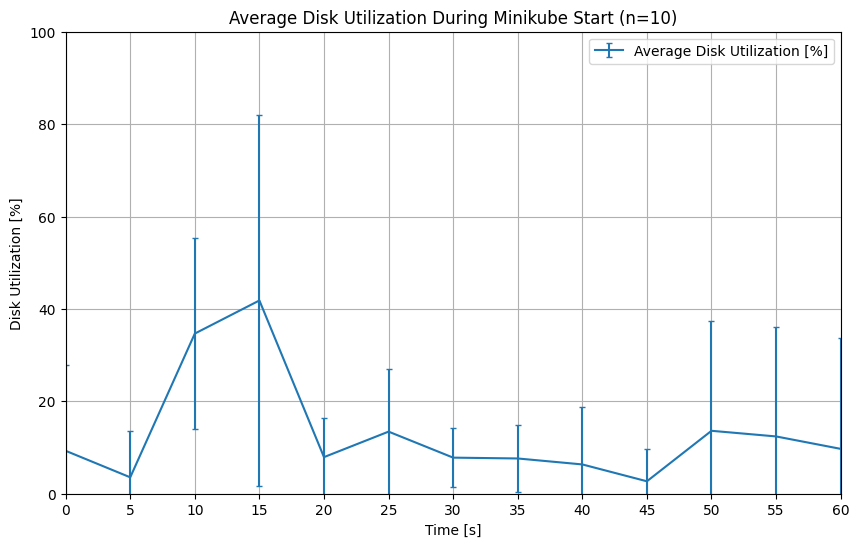

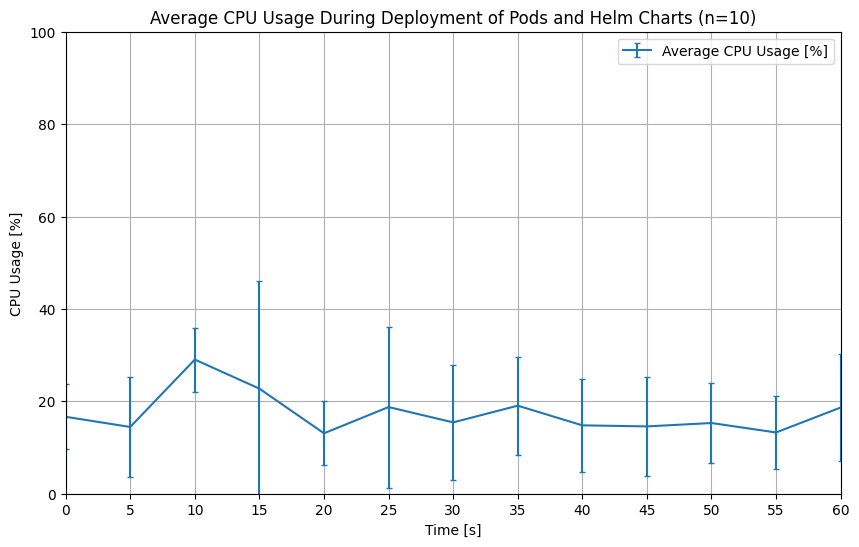

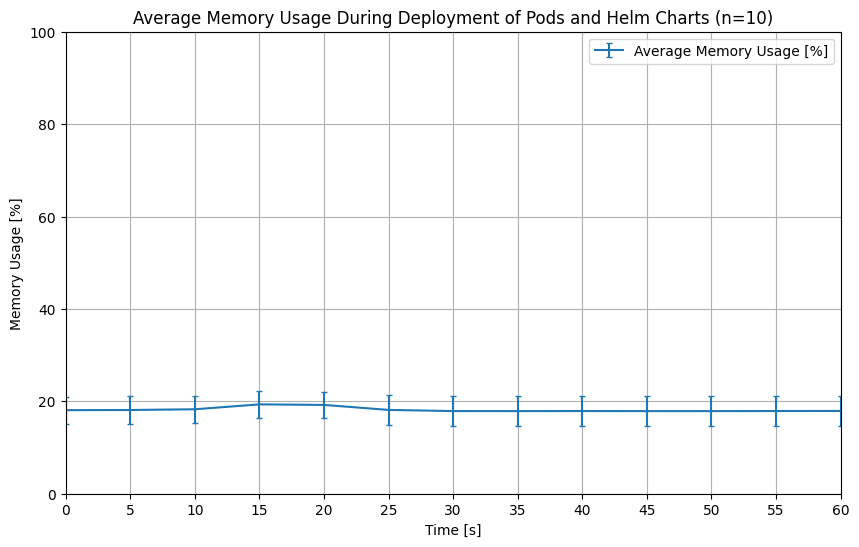

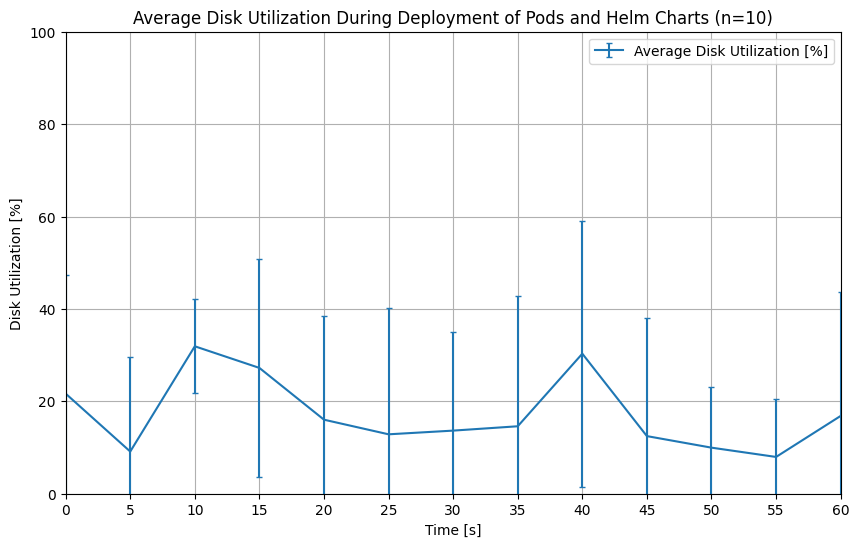

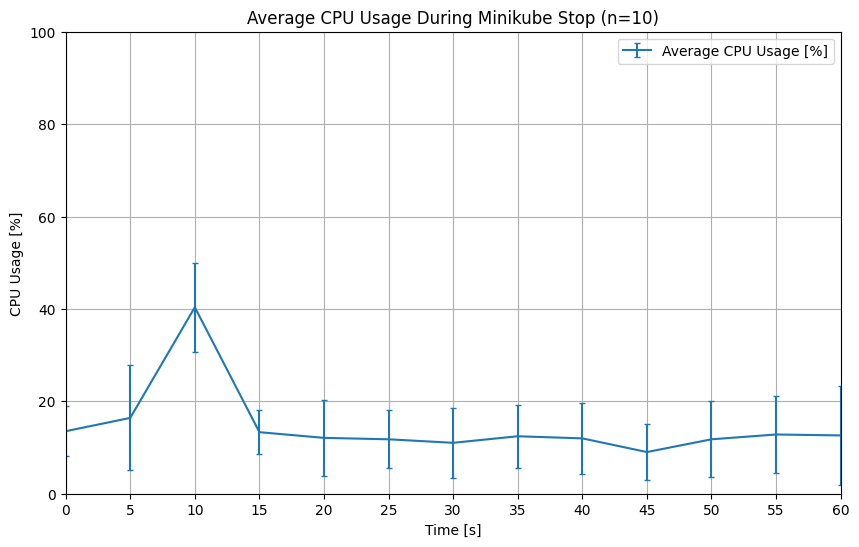

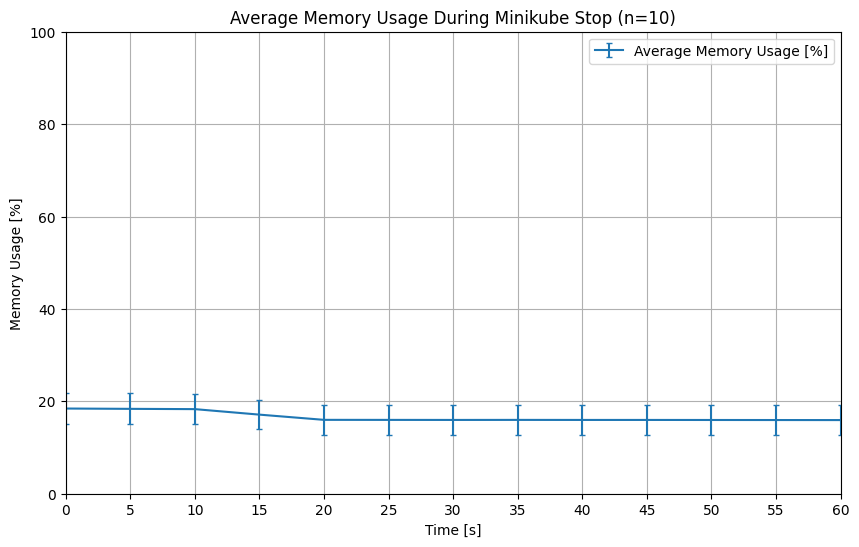

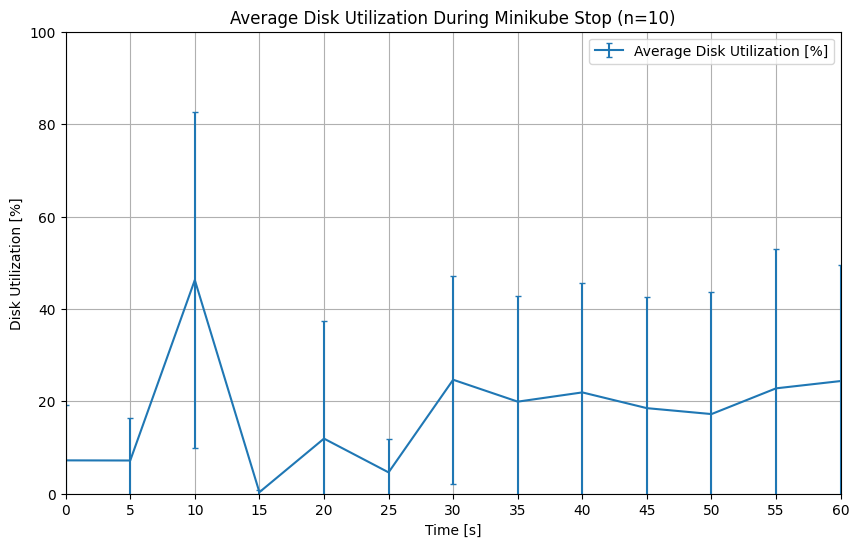

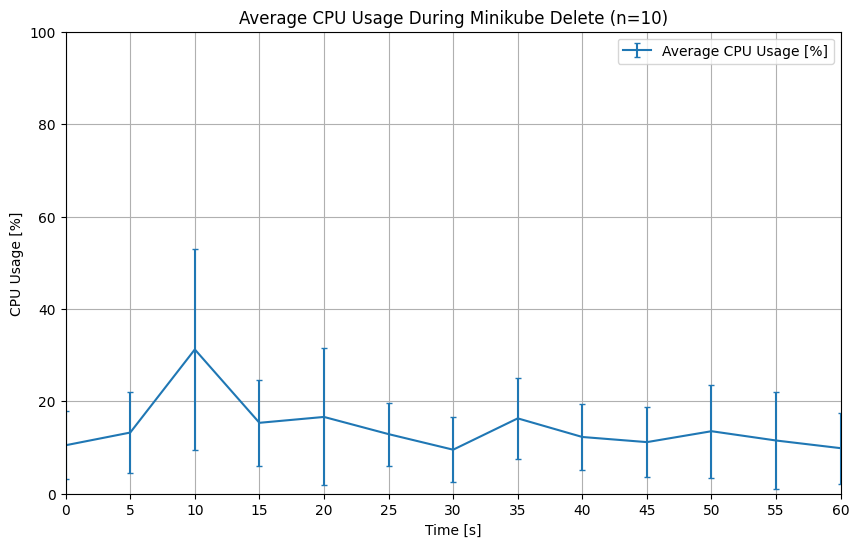

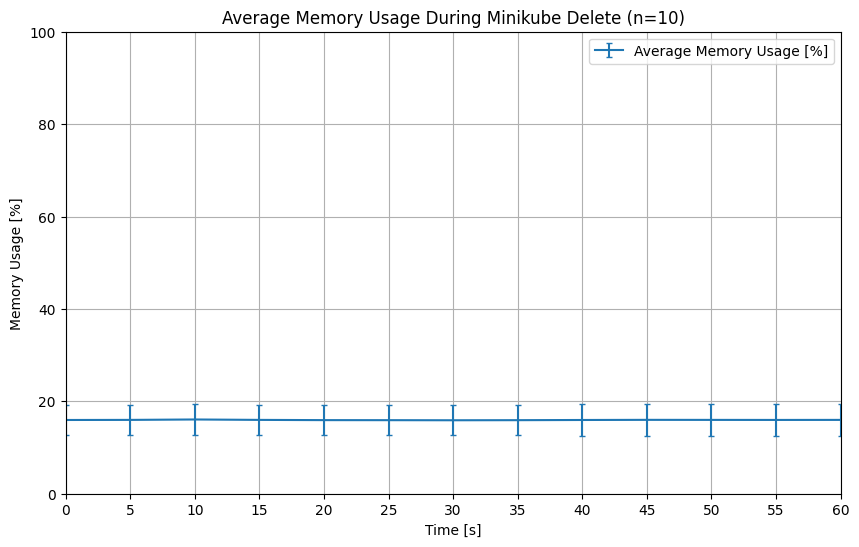

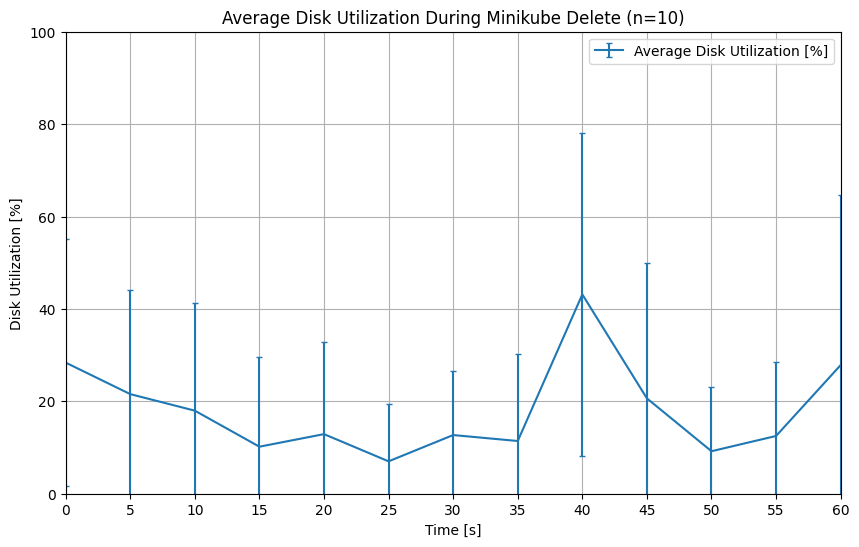

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

NUM_FILES = 10

phases_data = {
    'start': [],
    'deployment': [],
    'end': [],
    'delete': []
}

# Read all CSV files
for i in range(1, NUM_FILES + 1):
    phases_data['start'].append(pd.read_csv(f"minikube_cpu_mem_disk/start_{i}.csv"))
    phases_data['deployment'].append(pd.read_csv(f"minikube_cpu_mem_disk/deployment_{i}.csv"))
    phases_data['end'].append(pd.read_csv(f"minikube_cpu_mem_disk/end_{i}.csv"))
    phases_data['delete'].append(pd.read_csv(f"minikube_cpu_mem_disk/delete_{i}.csv"))

print(phases_data)

# Calculate averages and standard deviations for each phase
avg_metrics = {}
std_metrics = {}
for phase, dfs in phases_data.items():
    # Initialize DataFrames
    avg_metrics[phase] = pd.DataFrame()
    std_metrics[phase] = pd.DataFrame()
    
    # Find minimum length across all files for this phase
    min_length = min(len(df) for df in dfs)
    
    # Trim all dataframes to minimum length
    dfs_trimmed = [df.iloc[:min_length] for df in dfs]
    
    # Use timestamp from first file
    avg_metrics[phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
    
    # Calculate averages and std for each metric
    metrics = ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']
    for metric in metrics:
        values = np.array([df[metric].values[:min_length] for df in dfs])
        avg_metrics[phase][metric] = np.mean(values, axis=0)
        std_metrics[phase][metric] = np.std(values, axis=0)
    
    # print('Metric:',metric)
    # print('Phase', phase)
    # print(std_metrics[phase][metric])

# Plot averaged results with error bars
phase_names = {
    'start': "Minikube Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Minikube Stop",
    'delete': "Minikube Delete"
}

for phase, data in avg_metrics.items():
    # CPU Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['cpu_usage_percent'],
                yerr=std_metrics[phase]['cpu_usage_percent'],
                label='Average CPU Usage [%]',
                capsize=2)
    plt.title(f"Average CPU Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("CPU Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Memory Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['mem_usage_percent'],
                yerr=std_metrics[phase]['mem_usage_percent'],
                label='Average Memory Usage [%]',
                capsize=2)
    plt.title(f"Average Memory Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Memory Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Disk Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['disk_usage_percent'],
                yerr=std_metrics[phase]['disk_usage_percent'],
                label='Average Disk Utilization [%]',
                capsize=2)
    plt.title(f"Average Disk Utilization During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Disk Utilization [%]")
    plt.grid()
    plt.legend()
    plt.show()

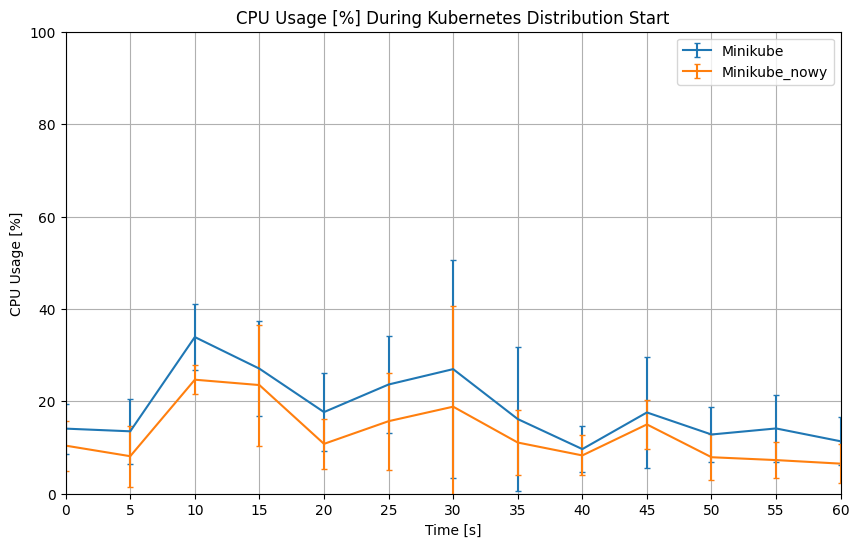

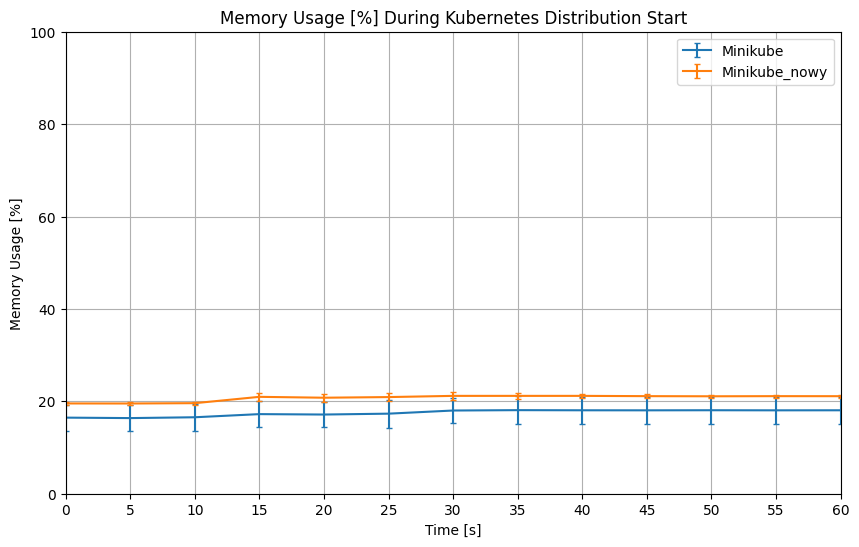

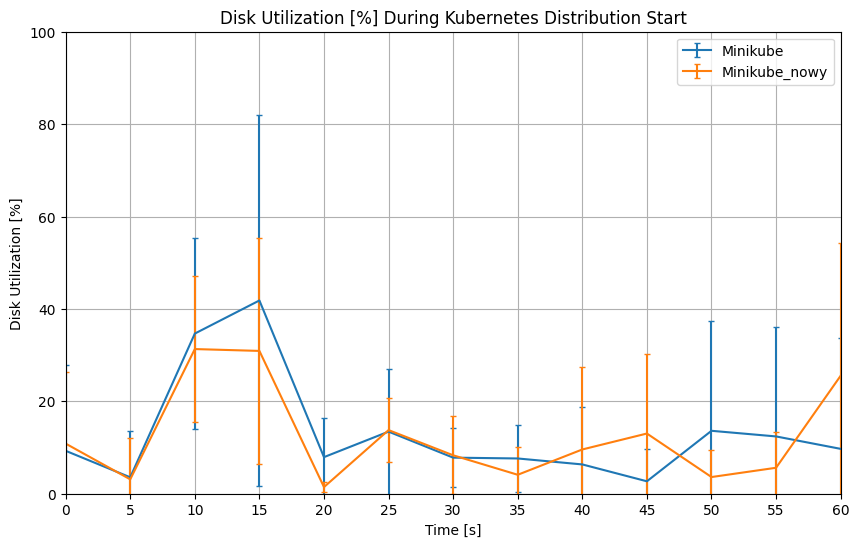

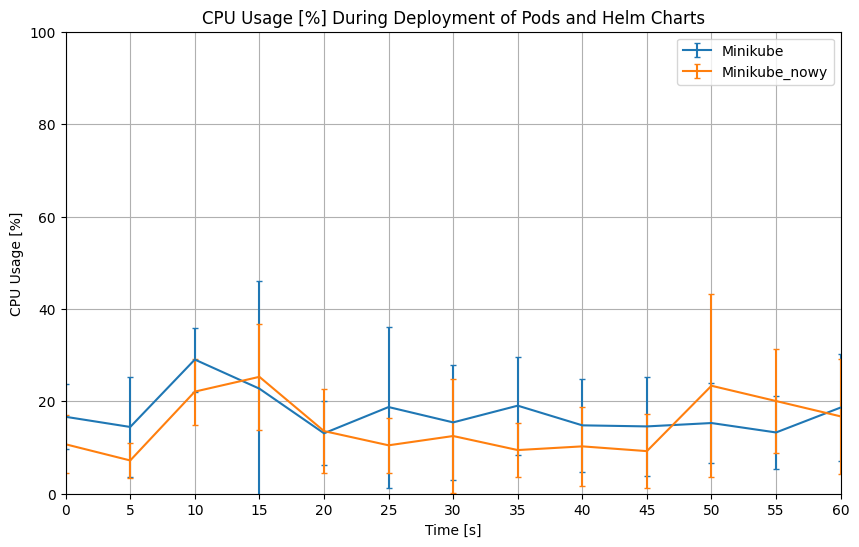

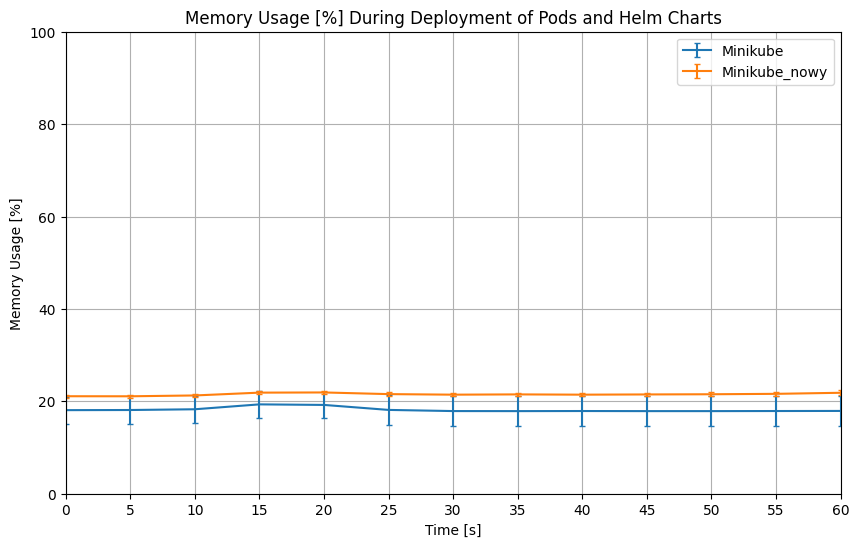

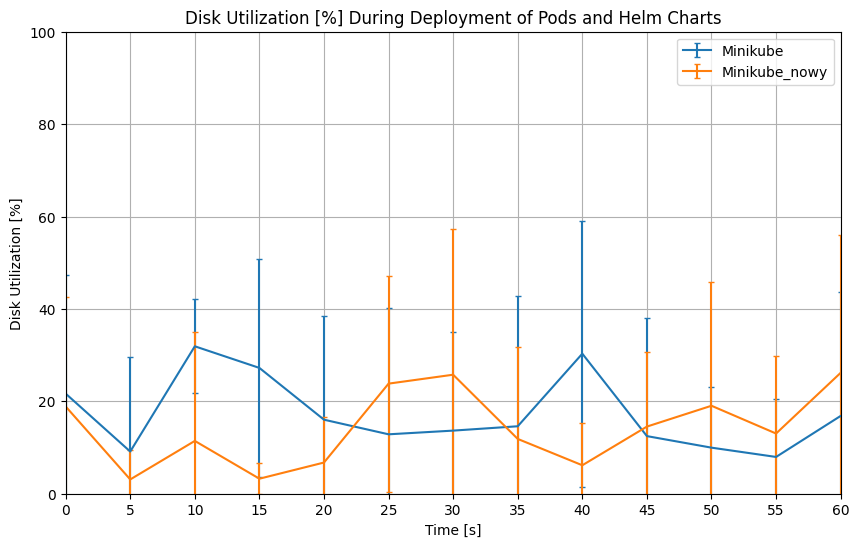

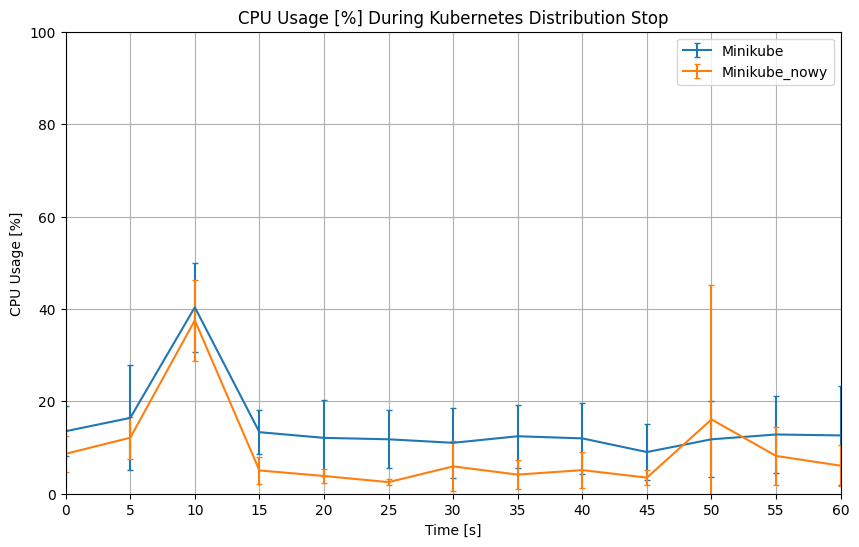

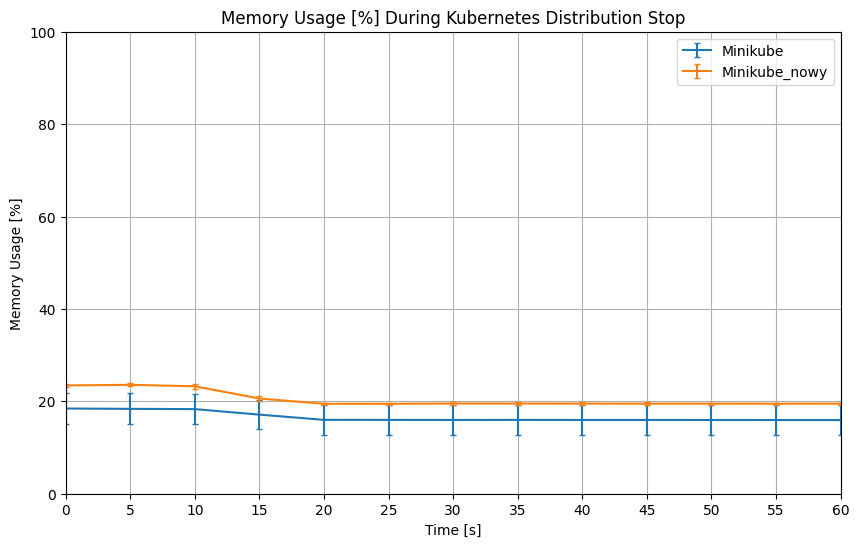

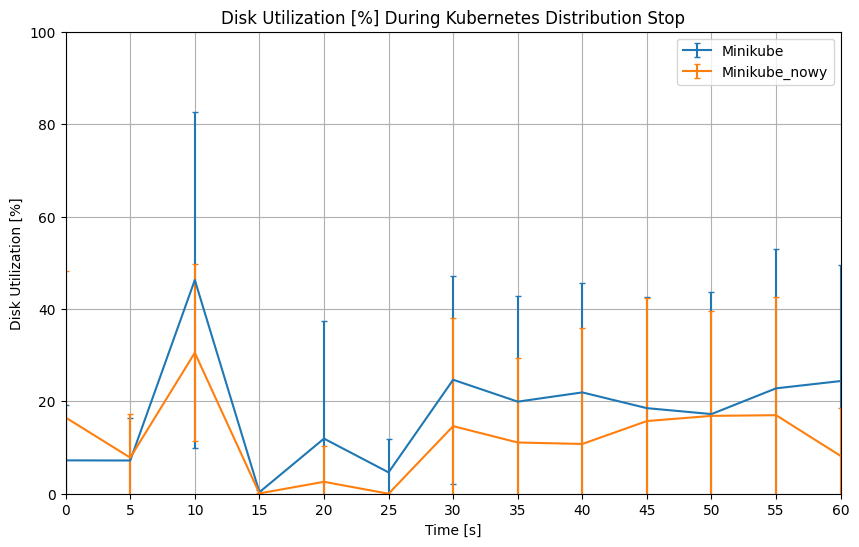

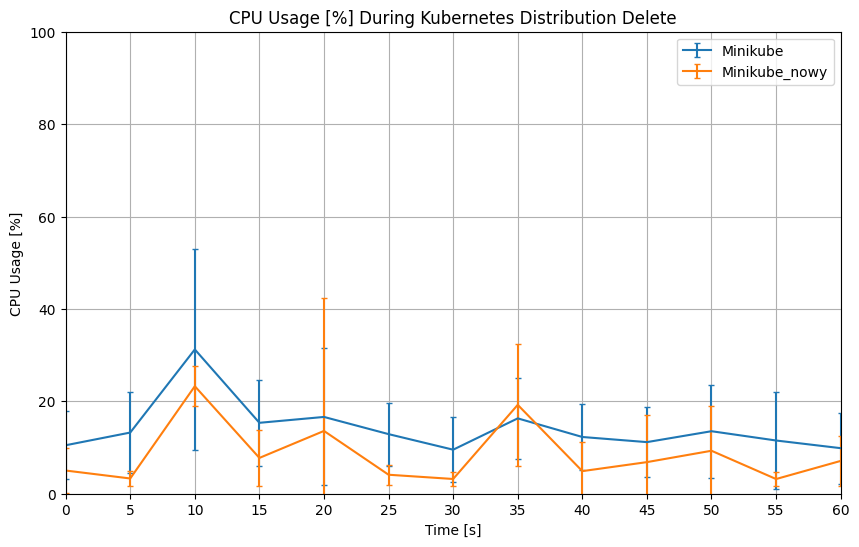

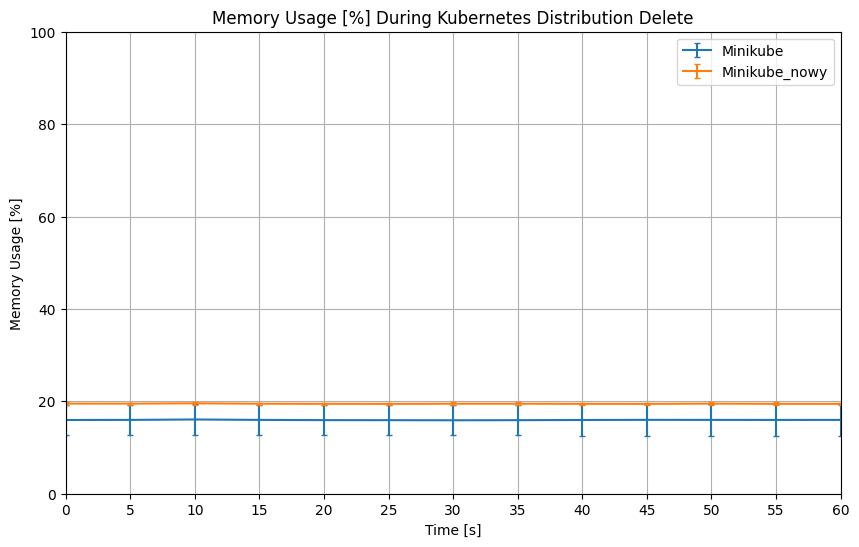

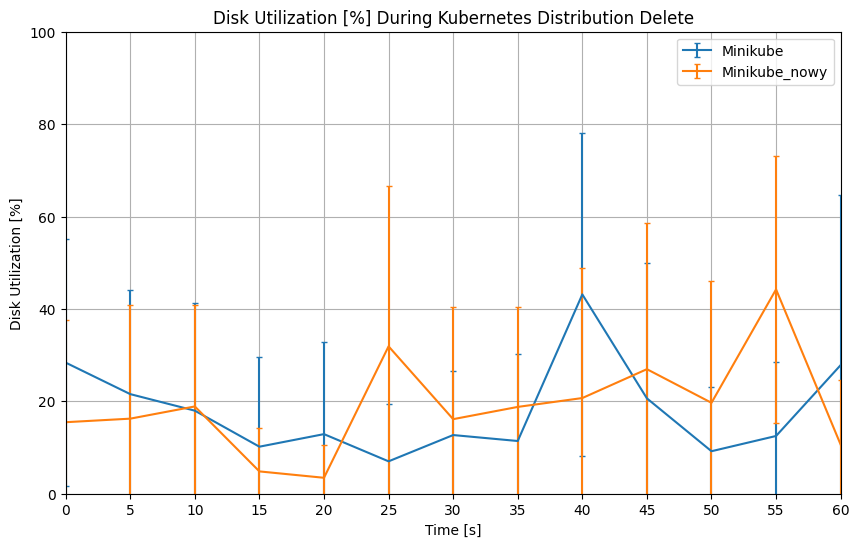

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

NUM_FILES = 10

# Define data sources
sources = {
    'minikube': 'minikube_cpu_mem_disk',
    'minikube_nowy': 'results'
}

# Initialize data structures
data = {
    source: {
        'start': [],
        'deployment': [],
        'end': [],
        'delete': []
    } for source in sources
}

# Read CSV files for both distributions
for source, directory in sources.items():
    for i in range(1, NUM_FILES + 1):
        for phase in data[source]:
            data[source][phase].append(pd.read_csv(f"{directory}/{phase}_{i}.csv"))

# Calculate metrics for both distributions
avg_metrics = {source: {} for source in sources}
std_metrics = {source: {} for source in sources}

for source in sources:
    for phase, dfs in data[source].items():
        avg_metrics[source][phase] = pd.DataFrame()
        std_metrics[source][phase] = pd.DataFrame()
        
        #TODO: usunąć jak będą dane z k3s
        min_length = min(len(df) for df in dfs)
        dfs_trimmed = [df.iloc[:min_length] for df in dfs]
        
        avg_metrics[source][phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
        
        for metric in ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']:
            values = np.array([df[metric].values[:min_length] for df in dfs])
            # dzięki axis=0 bierze po pierwszym elemencie z każdego DataFrame
            avg_metrics[source][phase][metric] = np.mean(values, axis=0)
            std_metrics[source][phase][metric] = np.std(values, axis=0)

# Define phases and metrics
phases = {
    'start': "Kubernetes Distribution Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Kubernetes Distribution Stop",
    'delete': "Kubernetes Distribution Delete"
}

metrics = {
    'cpu_usage_percent': 'CPU Usage [%]',
    'mem_usage_percent': 'Memory Usage [%]',
    'disk_usage_percent': 'Disk Utilization [%]'
}

for phase, phase_title in phases.items():
    for metric, metric_label in metrics.items():
        plt.figure(figsize=(10, 6))
        
        for source in sources:
            plt.errorbar(
                avg_metrics[source][phase]['timestamp'],
                avg_metrics[source][phase][metric],
                yerr=std_metrics[source][phase][metric],
                label=source.capitalize(),
                capsize=2
            )
        
        plt.title(f"{metric_label} During {phase_title}")
        plt.xlim(0, 60)
        plt.xticks(np.arange(0, 65, 5))
        plt.ylim(0, 100)
        plt.xlabel("Time [s]")
        plt.ylabel(metric_label)
        plt.grid(True)
        plt.legend()
        plt.show()

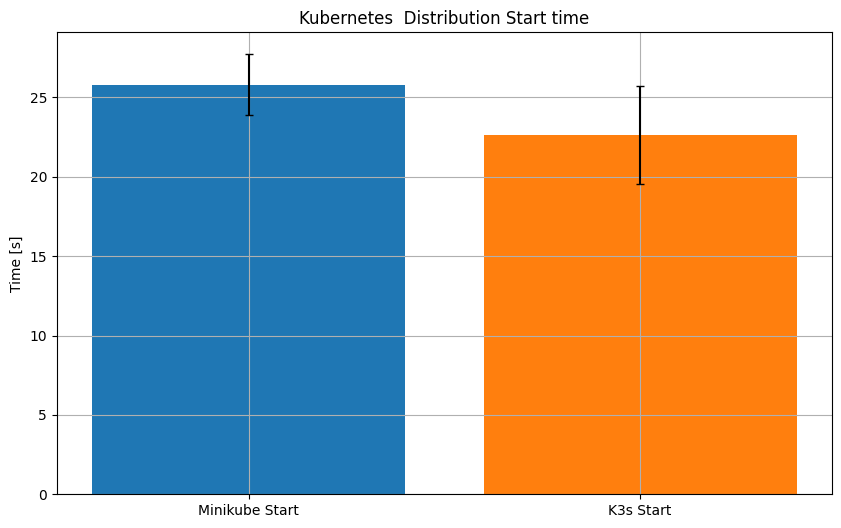

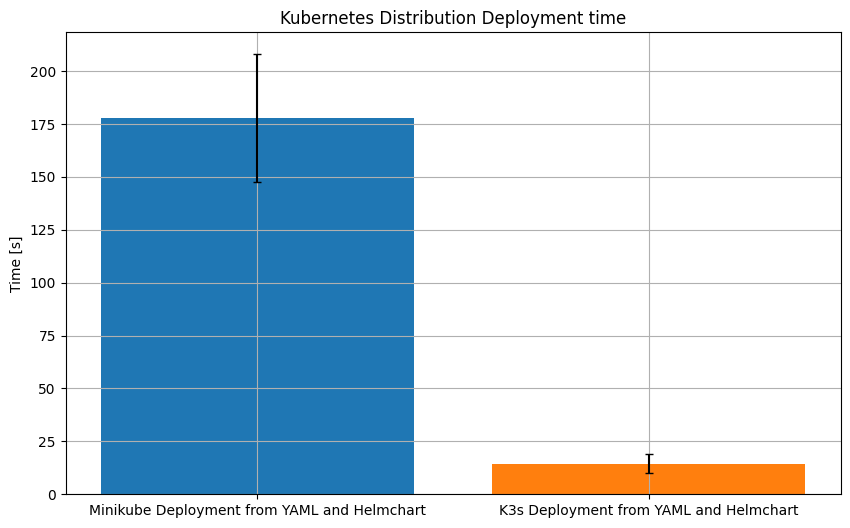

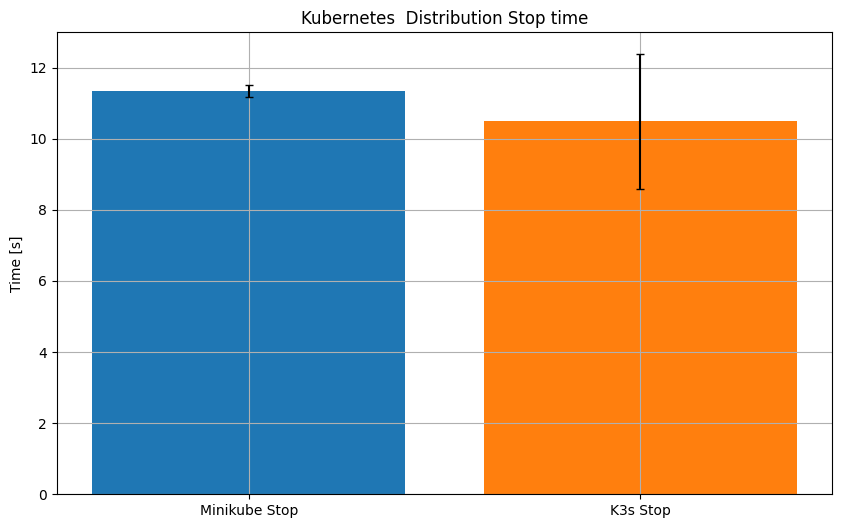

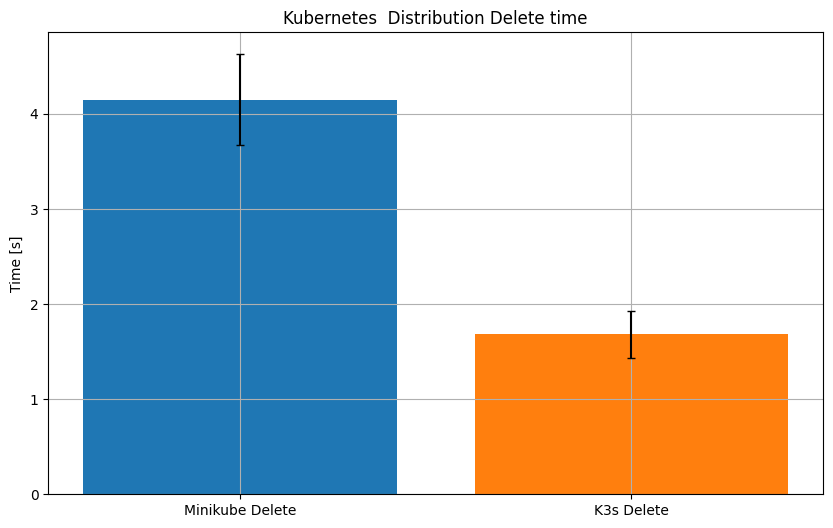

In [7]:
# zmienić to jak będzie reszta tych danych 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("minikube_time2.csv")
# tu ma być k3s
df2 = pd.read_csv("minikube_time.csv")

columns = {
    'start_time' : ["Kubernetes  Distribution Start time", "Minikube Start", "K3s Start"],
    'deployment_time' : ["Kubernetes Distribution Deployment time", "Minikube Deployment from YAML and Helmchart", "K3s Deployment from YAML and Helmchart"],
    'stop_time' : ["Kubernetes  Distribution Stop time", "Minikube Stop", "K3s Stop"], 
    'delete_time' : ["Kubernetes  Distribution Delete time", "Minikube Delete", "K3s Delete"]}
for metric, title in columns.items():
    stdev1 = np.std(df[metric])
    stdev2 = np.std(df2[metric])
    plt.figure(figsize=(10, 6))
    x = df[metric].mean()
    plt.bar(title[1], df[metric].mean(), yerr=stdev1, capsize=3)
    plt.bar(title[2], df2[metric].mean(), yerr=stdev2, capsize=3)
    # plt.errorbar(x, df[metric], yerr=stdev, capsize=3)
    plt.ylabel("Time [s]")
    plt.title(title[0])
    # plt.xticks(x)
    plt.grid()
    plt.show()

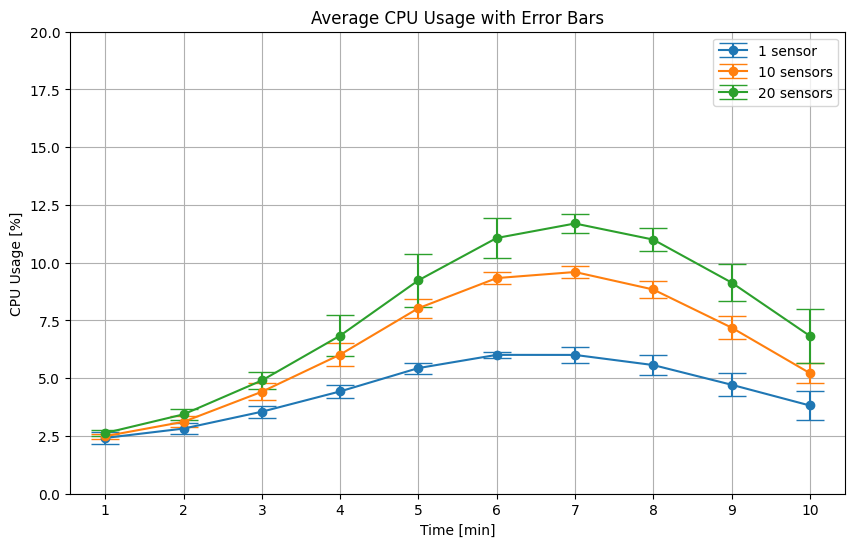

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cpu_1 = [2.6, 3.17, 4.58, 5.93, 8, 9.11, 9.22, 8.6, 7.01, 4.97, 3.66, 2.8, 2.43]
cpu_2 = [2.62, 3.50, 4.69, 6.61, 8.49, 9.64, 9.74, 8.42, 6.88, 4.79, 2,64, 2,69]
cpu_3 = [2.52, 3.01, 4.3, 5.6, 7.8, 9.1, 9.71, 9.06, 7.45, 5.04, 3.8, 2.8, 2.2]
cpu_4 = [2.38, 3.01, 4.31, 6.08, 8.06, 9.48, 9.86, 9.12, 7.38, 5.65, 3.75, 2.69]
cpu_5 = [2.48, 3.51, 4.42, 6.16, 8.15, 9.53, 9.79, 9.17, 7.47, 5.47, 3.9, 2.37]
cpu_6 = [2.47, 3.12, 4.36, 6.10, 8.08, 9.48, 9.65, 8.69, 7.24, 5.21, 3.76, 2.87]
cpu_7 = [2.62, 3.11, 5.17, 6.98, 8.64, 9.50, 9.13, 8.10, 5.90, 4.41, 3.01, 2.37]
cpu_8 = [2.42, 3, 4.15, 5.80, 7.72, 9.12, 9.65, 8.95, 7.38, 5.45, 4.04, 2.03]
cpu_9 = [2.48, 2.98, 4.41, 5.68, 8.18, 9.47, 9.86, 9.26, 7.57, 5.49, 3.84, 2.66]
cpu_10 = [2.32, 2.73, 3.74, 5.28, 7.19, 8.92, 9.37, 9.04, 7.64, 5.74, 4.06, 2.91]

cpu_1_1 = [2.47, 2.84, 3.58, 4.58, 5.56, 6.12, 6.15, 5.58, 4.63, 3.55, 2.9, 2.53]
cpu_2_1 = [2.58, 2.86, 3.51, 4.14, 5.09, 5.73, 6.14, 5.89, 5.17, 4.15, 2.6, 2.3]
cpu_3_1 = [2.18, 2.5, 3.13, 4.23, 5.27, 5.88, 5.17, 5.86, 5.05, 5.03, 3.18, 2.52]
cpu_4_1 = [2.17, 2.56, 3.31, 4.05, 5.28, 5.92, 6.19, 5.73, 4.86, 3.86, 3.07, 2.57]
cpu_5_1 = [2.52, 2.81, 3.51, 4.19, 5.21, 6.06, 6.47, 6.26, 5.5, 4.43, 3.47, 2.5]
cpu_6_1 = [1.94, 2.49, 3.34, 4.26, 5.40, 5.97, 5.96, 5.24, 4.44, 3.54, 2.8, 2.49]
cpu_7_1 = [2.54, 3.07, 3.81, 4.63, 5.65, 6.02, 5.85, 5.15, 4.09, 3.14, 2.45, 2.06]
cpu_8_1 = [2.52, 2.86, 3.5, 4.58, 5.41, 6.10, 6.29, 5.79, 5.08, 4.08, 3.21, 2.86]
cpu_9_1 = [2.76, 3.26, 4.01, 4.8, 5.80, 6.21, 6.10, 5.30, 4.46, 3.32, 2.65, 2.15]
cpu_10_1 = [2.47, 2.95, 3.80, 4.83, 5.72, 6.10, 5.77, 4.9, 3.9, 3.1, 2.44, 2.19]

cpu_1_20 = [2.64, 3.54, 5.13, 7.33, 9.78, 11.44, 11.68, 10.82, 8.69, 6.22, 4.02, 2.96, 2.33]
cpu_2_20 = [2.45, 3.5, 4.51, 7.15, 9.93, 11.33, 11.71, 10.38, 8.56, 5.74, 4.13, 2.81, 2.41]
cpu_3_20 = [2.73, 3.37, 5.14, 6.88, 9.33, 11.2, 11.88, 11.22, 8.86, 6.8, 4.73, 3.26, 2.5]
cpu_4_20 = [2.62, 3.47, 4.95, 7.18, 9.65, 11.32, 11.72, 10.50, 8.68, 6.22, 4.30, 3.07, 2.4]
cpu_5_20 = [2.77, 3.65, 5.16, 7.33, 9.82, 11.4, 11.7, 10.80, 8.68, 6.11, 4.30, 3.08, 2.59]
cpu_6_20 = [2.47, 3.13, 4.71, 6.35, 8.77, 11.11, 11.93, 11.56, 9.51, 7.5, 5, 3.48, 2.63]
cpu_7_20 = [2.52, 3.09, 4.33, 4.64, 6.23, 8.63, 10.62, 11.69, 11.09, 9.74, 7.37, 4.93, 2.81]
cpu_8_20 = [2.69, 3.42, 4.79, 6.81, 9.23, 11.22, 11.9, 11.33, 9.44, 6.97, 4.97, 3.32, 2.49]
cpu_9_20 = [2.49, 3.25, 4.66, 6.72, 9.21, 11.18, 11.9, 11.36, 9.54, 7.09, 4.9, 3.48, 2.69]
cpu_10_20 = [2.89, 3.94, 5.65, 8.03, 10.43, 11.87, 11.94, 10.35, 8.37, 5.94, 3.89, 2.93]


df1 = pd.DataFrame({
    '1': [cpu_1[0], cpu_2[0], cpu_3[0], cpu_4[0], cpu_5[0], cpu_6[0], cpu_7[0], cpu_8[0], cpu_9[0], cpu_10[0]],
    '2': [cpu_1[1], cpu_2[1], cpu_3[1], cpu_4[1], cpu_5[1], cpu_6[1], cpu_7[1], cpu_8[1], cpu_9[1], cpu_10[1]],
    '3': [cpu_1[2], cpu_2[2], cpu_3[2], cpu_4[2], cpu_5[2], cpu_6[2], cpu_7[2], cpu_8[2], cpu_9[2], cpu_10[2]], 
    '4': [cpu_1[3], cpu_2[3], cpu_3[3], cpu_4[3], cpu_5[3], cpu_6[3], cpu_7[3], cpu_8[3], cpu_9[3], cpu_10[3]],
    '5': [cpu_1[4], cpu_2[4], cpu_3[4], cpu_4[4], cpu_5[4], cpu_6[4], cpu_7[4], cpu_8[4], cpu_9[4], cpu_10[4]],
    '6': [cpu_1[5], cpu_2[5], cpu_3[5], cpu_4[5], cpu_5[5], cpu_6[5], cpu_7[5], cpu_8[5], cpu_9[5], cpu_10[5]],
    '7': [cpu_1[6], cpu_2[6], cpu_3[6], cpu_4[6], cpu_5[6], cpu_6[6], cpu_7[6], cpu_8[6], cpu_9[6], cpu_10[6]],
    '8': [cpu_1[7], cpu_2[7], cpu_3[7], cpu_4[7], cpu_5[7], cpu_6[7], cpu_7[7], cpu_8[7], cpu_9[7], cpu_10[7]],
    '9': [cpu_1[8], cpu_2[8], cpu_3[8], cpu_4[8], cpu_5[8], cpu_6[8], cpu_7[8], cpu_8[8], cpu_9[8], cpu_10[8]],
    '10': [cpu_1[9], cpu_2[9], cpu_3[9], cpu_4[9], cpu_5[9], cpu_6[9], cpu_7[9], cpu_8[9], cpu_9[9], cpu_10[9]]})

df2 = pd.DataFrame({
    '1' : [cpu_1_1[0], cpu_2_1[0], cpu_3_1[0], cpu_4_1[0], cpu_5_1[0], cpu_6_1[0], cpu_7_1[0], cpu_8_1[0], cpu_9_1[0], cpu_10_1[0]],
    '2' : [cpu_1_1[1], cpu_2_1[1], cpu_3_1[1], cpu_4_1[1], cpu_5_1[1], cpu_6_1[1], cpu_7_1[1], cpu_8_1[1], cpu_9_1[1], cpu_10_1[1]],
    '3' : [cpu_1_1[2], cpu_2_1[2], cpu_3_1[2], cpu_4_1[2], cpu_5_1[2], cpu_6_1[2], cpu_7_1[2], cpu_8_1[2], cpu_9_1[2], cpu_10_1[2]],
    '4' : [cpu_1_1[3], cpu_2_1[3], cpu_3_1[3], cpu_4_1[3], cpu_5_1[3], cpu_6_1[3], cpu_7_1[3], cpu_8_1[3], cpu_9_1[3], cpu_10_1[3]], 
    '5' : [cpu_1_1[4], cpu_2_1[4], cpu_3_1[4], cpu_4_1[4], cpu_5_1[4], cpu_6_1[4], cpu_7_1[4], cpu_8_1[4], cpu_9_1[4], cpu_10_1[4]],
    '6' : [cpu_1_1[5], cpu_2_1[5], cpu_3_1[5], cpu_4_1[5], cpu_5_1[5], cpu_6_1[5], cpu_7_1[5], cpu_8_1[5], cpu_9_1[5], cpu_10_1[5]],
    '7' : [cpu_1_1[6], cpu_2_1[6], cpu_3_1[6], cpu_4_1[6], cpu_5_1[6], cpu_6_1[6], cpu_7_1[6], cpu_8_1[6], cpu_9_1[6], cpu_10_1[6]],
    '8' : [cpu_1_1[7], cpu_2_1[7], cpu_3_1[7], cpu_4_1[7], cpu_5_1[7], cpu_6_1[7], cpu_7_1[7], cpu_8_1[7], cpu_9_1[7], cpu_10_1[7]],
    '9' : [cpu_1_1[8], cpu_2_1[8], cpu_3_1[8], cpu_4_1[8], cpu_5_1[8], cpu_6_1[8], cpu_7_1[8], cpu_8_1[8], cpu_9_1[8], cpu_10_1[8]],
    '10': [cpu_1_1[9], cpu_2_1[9], cpu_3_1[9], cpu_4_1[9], cpu_5_1[9], cpu_6_1[9], cpu_7_1[9], cpu_8_1[9], cpu_9_1[9], cpu_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [cpu_1_20[0], cpu_2_20[0], cpu_3_20[0], cpu_4_20[0], cpu_5_20[0], cpu_6_20[0], cpu_7_20[0], cpu_8_20[0], cpu_9_20[0], cpu_10_20[0]],
    '2' : [cpu_1_20[1], cpu_2_20[1], cpu_3_20[1], cpu_4_20[1], cpu_5_20[1], cpu_6_20[1], cpu_7_20[1], cpu_8_20[1], cpu_9_20[1], cpu_10_20[1]],
    '3' : [cpu_1_20[2], cpu_2_20[2], cpu_3_20[2], cpu_4_20[2], cpu_5_20[2], cpu_6_20[2], cpu_7_20[2], cpu_8_20[2], cpu_9_20[2], cpu_10_20[2]],
    '4' : [cpu_1_20[3], cpu_2_20[3], cpu_3_20[3], cpu_4_20[3], cpu_5_20[3], cpu_6_20[3], cpu_7_20[3], cpu_8_20[3], cpu_9_20[3], cpu_10_20[3]],
    '5' : [cpu_1_20[4], cpu_2_20[4], cpu_3_20[4], cpu_4_20[4], cpu_5_20[4], cpu_6_20[4], cpu_7_20[4], cpu_8_20[4], cpu_9_20[4], cpu_10_20[4]],
    '6' : [cpu_1_20[5], cpu_2_20[5], cpu_3_20[5], cpu_4_20[5], cpu_5_20[5], cpu_6_20[5], cpu_7_20[5], cpu_8_20[5], cpu_9_20[5], cpu_10_20[5]],
    '7' : [cpu_1_20[6], cpu_2_20[6], cpu_3_20[6], cpu_4_20[6], cpu_5_20[6], cpu_6_20[6], cpu_7_20[6], cpu_8_20[6], cpu_9_20[6], cpu_10_20[6]],
    '8' : [cpu_1_20[7], cpu_2_20[7], cpu_3_20[7], cpu_4_20[7], cpu_5_20[7], cpu_6_20[7], cpu_7_20[7], cpu_8_20[7], cpu_9_20[7], cpu_10_20[7]],
    '9' : [cpu_1_20[8], cpu_2_20[8], cpu_3_20[8], cpu_4_20[8], cpu_5_20[8], cpu_6_20[8], cpu_7_20[8], cpu_8_20[8], cpu_9_20[8], cpu_10_20[8]],
    '10': [cpu_1_20[9], cpu_2_20[9], cpu_3_20[9], cpu_4_20[9], cpu_5_20[9], cpu_6_20[9], cpu_7_20[9], cpu_8_20[9], cpu_9_20[9], cpu_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []
for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std()) 

for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1 sensor', '10 sensors', '20 sensors'])
plt.title("Average CPU Usage with Error Bars")
plt.ylim(0, 20)
plt.xlabel("Time [min]")
plt.ylabel("CPU Usage [%]")
plt.grid()
plt.show()

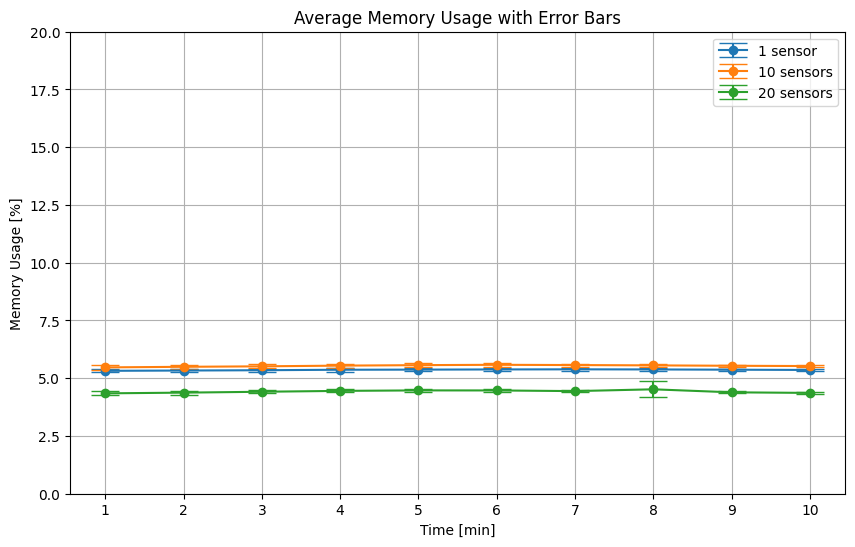

In [3]:


mem_1 = [5.25, 5.29, 5.35, 5.41, 5.45, 5.47, 5.48, 5.47, 5.45, 5.44]
mem_2 = [5.41, 5.41, 5.41, 5.43, 5.44, 5.45, 5.47, 5.47, 5.48, 5.46]
mem_3 = [5.4, 5.44, 5.44, 5.46, 5.48, 5.52, 5.52, 5.52, 5.51, 5.50]
mem_4 = [5.48, 5.49, 5.51, 5.54, 5.55, 5.55, 5.54, 5.52, 5.50, 5.49]
mem_5 = [5.50, 5.52, 5.53, 5.54, 5.55, 5.56, 5.55, 5.53, 5.52, 5.51]
mem_6 = [5.50, 5.52, 5.54, 5.58, 5.60, 5.61, 5.60, 5.59, 5.57, 5.57]
mem_7 = [5.55, 5.56, 5.57, 5.60, 5.62, 5.64, 5.62, 5.60, 5.58, 5.57]
mem_8 = [5.52, 5.53, 5.57, 5.60, 5.63, 5.66, 5.63, 5.60, 5.57, 5.56]
mem_9 = [5.54, 5.58, 5.61, 5.63, 5.67, 5.68, 5.65, 5.63, 5.61, 5.58]
mem_10 = [5.54, 5.60, 5.62, 5.66, 5.67, 5.67, 5.64, 5.63, 5.60, 5.59]


mem_1_1 = [5.25, 5.25, 5.26, 5.28, 5.29, 5.29, 5.30, 5.30, 5.30, 5.29]
mem_2_1 = [5.25, 5.25, 5.27, 5.29, 5.31, 5.33, 5.35, 5.36, 5.35, 5.33]
mem_3_1 = [5.28, 5.29, 5.30, 5.31, 5.32, 5.32, 5.33, 5.33, 5.32, 5.32]
mem_4_1 = [5.24, 5.25, 5.26, 5.27, 5.29, 5.31, 5.32, 5.33, 5.32, 5.32]
mem_5_1 = [5.30, 5.30, 5.31, 5.32, 5.34, 5.35, 5.36, 5.36, 5.35, 5.34]
mem_6_1 = [5.33, 5.36, 5.38, 5.39, 5.41, 5.42, 5.42, 5.42, 5.39, 5.37]
mem_7_1 = [5.42, 5.45, 5.46, 5.54, 5.44, 5.42, 5.42, 5.40, 5.39, 5.39]
mem_8_1 = [5.36, 5.38, 5.40, 5.42, 5.44, 5.46, 5.44, 5.41, 5.40, 5.38]
mem_9_1 = [5.39, 5.40, 5.42, 5.43, 5.45, 5.46, 5.46, 5.44, 5.42, 5.40]
mem_10_1 = [5.38, 5.40, 5.40, 5.42, 5.43, 5.44, 5.45, 5.45, 5.45, 5.44]


mem_1_20 = [4.11, 4.16, 4.25, 4.32, 4.35, 4.37, 4.34, 4.31, 4.28, 4.27]
mem_2_20 = [4.28, 4.29, 4.33, 4.36, 4.39, 4.41, 4.41, 4.48, 4.45, 4.38]
mem_3_20 = [4.37, 4.40, 4.42, 4.44, 4.47, 4.46, 4.42, 4.40, 4.37, 4.35]
mem_4_20 = [4.38, 4.42, 4.45, 4.49, 4.51, 4.51, 4.48, 4.45, 4.42, 4.40]
mem_5_20 = [4.40, 4.43, 4.46, 4.48, 4.51, 4.49, 4.46, 4.42, 4.39, 4.37]
mem_6_20 = [4.39, 4.43, 4.48, 4.52, 4.56, 4.57, 4.52, 5.48, 4.44, 4.39]
mem_7_20 = [4.38, 4.41, 4.45, 4.48, 4.49, 4.48, 4.45, 4.42, 4.39, 4.36]
mem_8_20 = [4.38, 4.40, 4.43, 4.48, 4.48, 4.47, 4.44, 4.41, 4.38, 4.36]
mem_9_20 = [4.37, 4.40, 4.43, 4.48, 4.50, 4.49, 4.46, 4.42, 4.39, 4.37]
mem_10_20 = [4.39, 4.42, 4.44, 4.47, 4.47, 4.46, 4.44, 4.41, 4.39, 4.39]


df1= pd.DataFrame({
    '1' : [mem_1[0], mem_2[0], mem_3[0], mem_4[0], mem_5[0], mem_6[0], mem_7[0], mem_8[0], mem_9[0], mem_10[0]],
    '2' : [mem_1[1], mem_2[1], mem_3[1], mem_4[1], mem_5[1], mem_6[1], mem_7[1], mem_8[1], mem_9[1], mem_10[1]],
    '3' : [mem_1[2], mem_2[2], mem_3[2], mem_4[2], mem_5[2], mem_6[2], mem_7[2], mem_8[2], mem_9[2], mem_10[2]],
    '4' : [mem_1[3], mem_2[3], mem_3[3], mem_4[3], mem_5[3], mem_6[3], mem_7[3], mem_8[3], mem_9[3], mem_10[3]],
    '5' : [mem_1[4], mem_2[4], mem_3[4], mem_4[4], mem_5[4], mem_6[4], mem_7[4], mem_8[4], mem_9[4], mem_10[4]],
    '6' : [mem_1[5], mem_2[5], mem_3[5], mem_4[5], mem_5[5], mem_6[5], mem_7[5], mem_8[5], mem_9[5], mem_10[5]],
    '7' : [mem_1[6], mem_2[6], mem_3[6], mem_4[6], mem_5[6], mem_6[6], mem_7[6], mem_8[6], mem_9[6], mem_10[6]],
    '8' : [mem_1[7], mem_2[7], mem_3[7], mem_4[7], mem_5[7], mem_6[7], mem_7[7], mem_8[7], mem_9[7], mem_10[7]],
    '9' : [mem_1[8], mem_2[8], mem_3[8], mem_4[8], mem_5[8], mem_6[8], mem_7[8], mem_8[8], mem_9[8], mem_10[8]],
    '10': [mem_1[9], mem_2[9], mem_3[9], mem_4[9], mem_5[9], mem_6[9], mem_7[9], mem_8[9], mem_9[9], mem_10[9]]})

df2 = pd.DataFrame({
    '1' : [mem_1_1[0], mem_2_1[0], mem_3_1[0], mem_4_1[0], mem_5_1[0], mem_6_1[0], mem_7_1[0], mem_8_1[0], mem_9_1[0], mem_10_1[0]],
    '2' : [mem_1_1[1], mem_2_1[1], mem_3_1[1], mem_4_1[1], mem_5_1[1], mem_6_1[1], mem_7_1[1], mem_8_1[1], mem_9_1[1], mem_10_1[1]],
    '3' : [mem_1_1[2], mem_2_1[2], mem_3_1[2], mem_4_1[2], mem_5_1[2], mem_6_1[2], mem_7_1[2], mem_8_1[2], mem_9_1[2], mem_10_1[2]],
    '4' : [mem_1_1[3], mem_2_1[3], mem_3_1[3], mem_4_1[3], mem_5_1[3], mem_6_1[3], mem_7_1[3], mem_8_1[3], mem_9_1[3], mem_10_1[3]],
    '5' : [mem_1_1[4], mem_2_1[4], mem_3_1[4], mem_4_1[4], mem_5_1[4], mem_6_1[4], mem_7_1[4], mem_8_1[4], mem_9_1[4], mem_10_1[4]],
    '6' : [mem_1_1[5], mem_2_1[5], mem_3_1[5], mem_4_1[5], mem_5_1[5], mem_6_1[5], mem_7_1[5], mem_8_1[5], mem_9_1[5], mem_10_1[5]],
    '7' : [mem_1_1[6], mem_2_1[6], mem_3_1[6], mem_4_1[6], mem_5_1[6], mem_6_1[6], mem_7_1[6], mem_8_1[6], mem_9_1[6], mem_10_1[6]],
    '8' : [mem_1_1[7], mem_2_1[7], mem_3_1[7], mem_4_1[7], mem_5_1[7], mem_6_1[7], mem_7_1[7], mem_8_1[7], mem_9_1[7], mem_10_1[7]],
    '9' : [mem_1_1[8], mem_2_1[8], mem_3_1[8], mem_4_1[8], mem_5_1[8], mem_6_1[8], mem_7_1[8], mem_8_1[8], mem_9_1[8], mem_10_1[8]],
    '10': [mem_1_1[9], mem_2_1[9], mem_3_1[9], mem_4_1[9], mem_5_1[9], mem_6_1[9], mem_7_1[9], mem_8_1[9], mem_9_1[9], mem_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [mem_1_20[0], mem_2_20[0], mem_3_20[0], mem_4_20[0], mem_5_20[0], mem_6_20[0], mem_7_20[0], mem_8_20[0], mem_9_20[0], mem_10_20[0]],
    '2' : [mem_1_20[1], mem_2_20[1], mem_3_20[1], mem_4_20[1], mem_5_20[1], mem_6_20[1], mem_7_20[1], mem_8_20[1], mem_9_20[1], mem_10_20[1]],
    '3' : [mem_1_20[2], mem_2_20[2], mem_3_20[2], mem_4_20[2], mem_5_20[2], mem_6_20[2], mem_7_20[2], mem_8_20[2], mem_9_20[2], mem_10_20[2]],
    '4' : [mem_1_20[3], mem_2_20[3], mem_3_20[3], mem_4_20[3], mem_5_20[3], mem_6_20[3], mem_7_20[3], mem_8_20[3], mem_9_20[3], mem_10_20[3]],
    '5' : [mem_1_20[4], mem_2_20[4], mem_3_20[4], mem_4_20[4], mem_5_20[4], mem_6_20[4], mem_7_20[4], mem_8_20[4], mem_9_20[4], mem_10_20[4]],
    '6' : [mem_1_20[5], mem_2_20[5], mem_3_20[5], mem_4_20[5], mem_5_20[5], mem_6_20[5], mem_7_20[5], mem_8_20[5], mem_9_20[5], mem_10_20[5]],
    '7' : [mem_1_20[6], mem_2_20[6], mem_3_20[6], mem_4_20[6], mem_5_20[6], mem_6_20[6], mem_7_20[6], mem_8_20[6], mem_9_20[6], mem_10_20[6]],
    '8' : [mem_1_20[7], mem_2_20[7], mem_3_20[7], mem_4_20[7], mem_5_20[7], mem_6_20[7], mem_7_20[7], mem_8_20[7], mem_9_20[7], mem_10_20[7]],
    '9' : [mem_1_20[8], mem_2_20[8], mem_3_20[8], mem_4_20[8], mem_5_20[8], mem_6_20[8], mem_7_20[8], mem_8_20[8], mem_9_20[8], mem_10_20[8]],
    '10': [mem_1_20[9], mem_2_20[9], mem_3_20[9], mem_4_20[9], mem_5_20[9], mem_6_20[9], mem_7_20[9], mem_8_20[9], mem_9_20[9], mem_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())


for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std())


for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1 sensor', '10 sensors', '20 sensors'])
plt.title("Average Memory Usage with Error Bars")
plt.ylim(0, 20)
plt.xlabel("Time [min]")
plt.ylabel("Memory Usage [%]")
plt.grid()
plt.show()